# 00 — Extracción de datos ChEMBL (Flujo A ampliado)

Descarga de bioactividad ChEMBL para el **corpus panameño completo** (~235 compuestos PubChem HID72 + 20 MIDA), con tipos de actividad ampliados y imputación de pChEMBL.

**Pipeline:**
1. Cargar compuestos desde `pubchem_panama_cids.csv` (`corpus_mode`: `full` o `mida`)
2. Resolver `molecule_chembl_id` por SMILES / nombre (incluye `NaN` para trazabilidad)
3. Descargar actividades IC50, EC50, Ki, Kd, Potency, Inhibition, AC50, LC50, GI50, etc. (**raw**)
4. Enriquecer con propiedades moleculares, diana y ensayo
5. Derivar `activity_class` (Active si pChEMBL ≥ 6)
6. Imputar pChEMBL desde `standard_value` (nM) y aplicar filtros de calidad

**Salidas:**
- `data/raw/chembl_corpus_compounds.csv`
- `data/raw/chembl_corpus_mapping.csv`
- `data/raw/chembl_panama_bioactivity_raw.csv`
- `data/raw/chembl_panama_bioactivity.csv`

**Fuente de datos (por defecto):** ChEMBLdb **SQLite local** (`data/external/chembl/chembl_37.db`) — sin llamadas HTTP.

**Setup único (Docker):**
```bash
docker compose -f docker/docker-compose.yml --profile setup run chembl-init
```

**Fallback:** `CHEMBL_BACKEND=api` o `backend="api"` en las funciones de extracción (API REST).

## 0. Configuración

In [1]:
import importlib
import sys
from pathlib import Path

ROOT = Path.cwd().parent.parent if Path.cwd().name == "proyecto analisis de datos" else (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

import os

# Recargar módulos tras cambios (evita caché del kernel)
import src.analisis_proyecto.chembl_extract as chembl_extract
import src.analisis_proyecto.chembl_local as chembl_local
importlib.reload(chembl_local)
importlib.reload(chembl_extract)

from src.data.pubchem_api import MIDA_ACTIVE_INGREDIENTS
from src.analisis_proyecto.chembl_extract import (
    apply_quality_filters_from_config,
    build_bioactivity_table,
    build_mapping_table,
    load_chembl_config,
    load_corpus_compounds,
    resolve_corpus_mode,
    resolve_standard_types,
    summarize_extraction,
)
from src.analisis_proyecto.chembl_api import PCHEMBL_ACTIVE_THRESHOLD
from src.analisis_proyecto.chembl_local import db_info, ensure_db_exists

CHEMBL_CFG = load_chembl_config(ROOT / "config" / "config.yaml")
CHEMBL_BACKEND = os.environ.get("CHEMBL_BACKEND", CHEMBL_CFG.get("backend", "sqlite"))
CORPUS_MODE = os.environ.get("CHEMBL_CORPUS_MODE", resolve_corpus_mode(CHEMBL_CFG))
STANDARD_TYPES = resolve_standard_types(CHEMBL_CFG)
CHEMBL_DB = Path(os.environ.get("CHEMBL_DB_PATH", CHEMBL_CFG["db_path"]))
if not CHEMBL_DB.is_absolute():
    CHEMBL_DB = ROOT / CHEMBL_DB

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

CORPUS_CSV = ROOT / "data" / "raw" / "pubchem_panama_cids.csv"
OUT_DIR = ROOT / "data" / "raw"
FIG_DIR = ROOT / "outputs" / "chembl"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

COMPOUNDS_CSV = OUT_DIR / "chembl_corpus_compounds.csv"
MAPPING_CSV = OUT_DIR / "chembl_corpus_mapping.csv"
RAW_CSV = OUT_DIR / "chembl_panama_bioactivity_raw.csv"
CLEAN_CSV = OUT_DIR / "chembl_panama_bioactivity.csv"

print(f"Raíz del proyecto: {ROOT}")
print(f"Corpus PubChem: {CORPUS_CSV}")
print(f"Modo corpus: {CORPUS_MODE}")
print(f"Backend ChEMBL: {CHEMBL_BACKEND}")
print(f"Tipos de actividad: {len(STANDARD_TYPES)} ({', '.join(STANDARD_TYPES[:5])}…)")
print(f"Umbral activity_class: pChEMBL >= {PCHEMBL_ACTIVE_THRESHOLD}")

if CHEMBL_BACKEND == "sqlite":
    try:
        ensure_db_exists(CHEMBL_DB)
        info = db_info(CHEMBL_DB)
        print(f"ChEMBLdb: {CHEMBL_DB} ({info['db_size_bytes'] / 1e9:.2f} GB)")
    except FileNotFoundError as exc:
        print(f"[WARN] {exc}")
        print("  → docker compose -f docker/docker-compose.yml --profile setup run chembl-init")
else:
    print("Modo API REST — puede ser lento o fallar con errores 500 del servidor EBI.")

Raíz del proyecto: c:\Users\mateo\Desktop\JIC2026
Corpus PubChem: c:\Users\mateo\Desktop\JIC2026\data\raw\pubchem_panama_cids.csv
Modo corpus: full
Backend ChEMBL: sqlite
Tipos de actividad: 13 (IC50, EC50, Ki, Kd, Potency…)
Umbral activity_class: pChEMBL >= 6.0
ChEMBLdb: c:\Users\mateo\Desktop\JIC2026\data\external\chembl\chembl_37.db (30.48 GB)


## 1. Carga del corpus

Por defecto (`corpus_mode=full`) se incluyen **todos** los compuestos de `pubchem_panama_cids.csv` con SMILES válido (~235 filas: MIDA + familias HID72).

Para volver al subconjunto de 20 MIDA: `CHEMBL_CORPUS_MODE=mida` o `corpus_mode: mida` en `config.yaml`.

In [2]:
assert CORPUS_CSV.exists(), (
    f"No se encontró {CORPUS_CSV}. Ejecuta: make build-panama-corpus"
)

compounds_df = load_corpus_compounds(CORPUS_CSV, mode=CORPUS_MODE)

print(f"Modo corpus: {CORPUS_MODE}")
print(f"Compuestos cargados: {len(compounds_df)}")
if "is_mida" in compounds_df.columns:
    print(f"  → MIDA: {compounds_df['is_mida'].sum()}")
    print(f"  → Familias HID72 / otros: {(~compounds_df['is_mida']).sum()}")
print(f"Familias químicas: {compounds_df['family'].nunique()}")

invalid_smiles = compounds_df["smiles"].isna() | (compounds_df["smiles"].astype(str).str.strip() == "")
print(f"SMILES inválidos/vacíos: {invalid_smiles.sum()}")

display(compounds_df.head(10))
compounds_df.to_csv(COMPOUNDS_CSV, index=False)
print(f"\nGuardado: {COMPOUNDS_CSV}")

Modo corpus: full
Compuestos cargados: 235
  → MIDA: 20
  → Familias HID72 / otros: 215
Familias químicas: 7
SMILES inválidos/vacíos: 0


[14:22:18] WARNING: not removing hydrogen atom without neighbors


,compound_name,pubchem_cid,smiles,family,source,is_mida
0,Chlorpyrifos,2730,CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl,mixed,MIDA_name_search,True
1,Malathion,4004,CCOC(=O)CC(SP(=S)(OC)OC)C(=O)OCC,mixed,MIDA_name_search,True
2,Dimethoate,3082,CNC(=O)CSP(=S)(OC)OC,mixed,MIDA_name_search,True
3,Methyl parathion,4130,COP(=S)(OC)Oc1ccc([N+](=O)[O-])cc1,mixed,MIDA_name_search,True
4,Carbaryl,6129,CNC(=O)Oc1cccc2ccccc12,mixed,MIDA_name_search,True
5,Methomyl,4109,CNC(=O)ON=C(C)SC,mixed,MIDA_name_search,True
6,Aldicarb,9570071,CNC(=O)O/N=C/C(C)(C)SC,mixed,MIDA_name_search,True
7,Atrazine,2256,CCNc1nc(Cl)nc(NC(C)C)n1,mixed,MIDA_name_search,True
8,Simazine,5216,CCNc1nc(Cl)nc(NCC)n1,mixed,MIDA_name_search,True
9,Tebuconazole,86102,CC(C)(C)C(O)(CCc1ccc(Cl)cc1)Cn1cncn1,mixed,MIDA_name_search,True



Guardado: c:\Users\mateo\Desktop\JIC2026\data\raw\chembl_corpus_compounds.csv


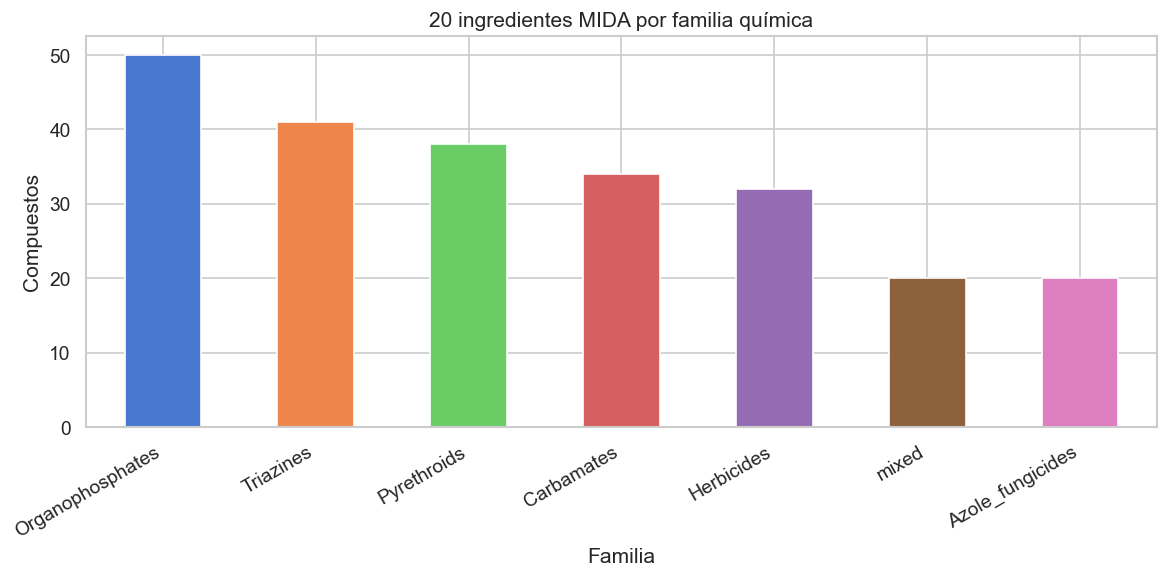

In [3]:
fam_counts = compounds_df["family"].value_counts()
fig, ax = plt.subplots()
fam_counts.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(fam_counts)))
ax.set_title("20 ingredientes MIDA por familia química")
ax.set_xlabel("Familia")
ax.set_ylabel("Compuestos")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "mida_compounds_by_family.png", bbox_inches="tight")
plt.show()

## 2. Mapeo PubChem → ChEMBL

Estrategia en cascada: xref PubChem → SMILES → `pref_name` → sinónimo.
Si no hay match, se conserva `chembl_id = NaN` para trazabilidad.

In [4]:
print(f"Resolviendo ChEMBL IDs (backend={CHEMBL_BACKEND})...\n")
mapping_df = build_mapping_table(
    compounds_df,
    backend=CHEMBL_BACKEND,
    db_path=CHEMBL_DB,
    verbose=True,
    existing_mapping_path=MAPPING_CSV,
    skip_resolved=True,
)

n_ok = (mapping_df["match_status"].isin(["ok", "ambiguous"])).sum()
n_nf = (mapping_df["match_status"] == "not_found").sum()

print(f"\nMatch OK/ambiguo: {n_ok} | No encontrados: {n_nf}")
display(mapping_df)
mapping_df.to_csv(MAPPING_CSV, index=False)
print(f"Guardado: {MAPPING_CSV}")

Resolviendo ChEMBL IDs (backend=sqlite)...

  Chlorpyrifos: reutilizado (CHEMBL463210)
  Malathion: reutilizado (CHEMBL1200468)
  Dimethoate: reutilizado (CHEMBL1569524)
  Methyl parathion: reutilizado (CHEMBL346516)
  Carbaryl: reutilizado (CHEMBL46917)
  Methomyl: reutilizado (CHEMBL552761)
  Aldicarb: reutilizado (CHEMBL91732)
  Atrazine: reutilizado (CHEMBL15063)
  Simazine: reutilizado (CHEMBL5775)
  Tebuconazole: reutilizado (CHEMBL8937)
  Propiconazole: reutilizado (CHEMBL174240)
  Difenoconazole: reutilizado (CHEMBL91495)
  Cypermethrin: reutilizado (CHEMBL3033792)
  Deltamethrin: reutilizado (CHEMBL416)
  Lambda-cyhalothrin: reutilizado (CHEMBL64147)
  Glyphosate: reutilizado (CHEMBL9571438)
  Paraquat: reutilizado (CHEMBL13958)
  2,4-D: reutilizado (CHEMBL7715)
  Mancozeb: reutilizado (CHEMBL1200543)
  Chlorothalonil: reutilizado (CHEMBL468167)
  CID_119: reutilizado (CHEMBL96)
  Mapeando (SQLite): CID_152
  CID_205: reutilizado (CHEMBL30037)
  CID_222: reutilizado (CHEMBL116

[14:22:40] WARNING: not removing hydrogen atom without neighbors


  CID_784: reutilizado (CHEMBL71595)
  CID_787: reutilizado (CHEMBL1191361)
  CID_887: reutilizado (CHEMBL14688)
  Mapeando (SQLite): CID_892
  Mapeando (SQLite): CID_935
  CID_945: reutilizado (CHEMBL1234765)
  CID_947: reutilizado (CHEMBL142438)
  CID_962: reutilizado (CHEMBL1098659)
  CID_977: reutilizado (CHEMBL1234886)
  CID_992: reutilizado (CHEMBL75967)
  CID_996: reutilizado (CHEMBL14060)
  CID_1004: reutilizado (CHEMBL1187)
  CID_1023: reutilizado (CHEMBL1160571)
  CID_1030: reutilizado (CHEMBL286398)
  CID_1031: reutilizado (CHEMBL14687)
  CID_1065: reutilizado (CHEMBL15088)
  Mapeando (SQLite): CID_1070
  Mapeando (SQLite): CID_1084
  CID_1110: reutilizado (CHEMBL576)
  CID_1118: reutilizado (CHEMBL572964)
  CID_1130: reutilizado (CHEMBL1547)
  CID_1140: reutilizado (CHEMBL9113)
  Mapeando (SQLite): CID_1143
  CID_1176: reutilizado (CHEMBL985)
  CID_1326: reutilizado (CHEMBL74063)
  CID_1474: reutilizado (CHEMBL39879)
  CID_1982: reutilizado (CHEMBL2133249)
  CID_34: reutili

,compound_name,pubchem_cid,smiles,family,chembl_id,match_method,match_status,n_candidates,chembl_pref_name
0,Chlorpyrifos,2730,CCOP(=S)(OCC)Oc1nc(Cl)c(Cl)cc1Cl,mixed,CHEMBL463210,known_registry,ok,1,CHLORPYRIFOS
1,Malathion,4004,CCOC(=O)CC(SP(=S)(OC)OC)C(=O)OCC,mixed,CHEMBL1200468,known_registry,ok,1,MALATHION
2,Dimethoate,3082,CNC(=O)CSP(=S)(OC)OC,mixed,CHEMBL1569524,known_registry,ok,1,DIMETHOATE
3,Methyl parathion,4130,COP(=S)(OC)Oc1ccc([N+](=O)[O-])cc1,mixed,CHEMBL346516,known_registry,ok,1,METHYL PARATHIONE
4,Carbaryl,6129,CNC(=O)Oc1cccc2ccccc12,mixed,CHEMBL46917,known_registry,ok,1,CARBARIL
...,...,...,...,...,...,...,...,...,...
230,CID_4610,4610,NC1CCCCC1N,Herbicides,CHEMBL1356279,sqlite_smiles,ok,1,NaN
231,CID_4756,4756,Nc1ccc(N=Nc2ccccc2)c(N)n1,Herbicides,CHEMBL1625467,sqlite_smiles,ok,1,NaN
232,CID_4781,4781,CCCCC1C(=O)N(c2ccccc2)N(c2ccccc2)C1=O,Herbicides,CHEMBL101,sqlite_smiles,ok,1,PHENYLBUTAZONE
233,CID_4933,4933,CCC(=O)Nc1ccc(Cl)c(Cl)c1,Herbicides,CHEMBL1222498,sqlite_smiles,ok,1,PROPANIL


Guardado: c:\Users\mateo\Desktop\JIC2026\data\raw\chembl_corpus_mapping.csv


## 3. Descarga de bioactividad (raw)

Se descargan registros de **13 tipos de actividad** (IC50, EC50, Ki, Kd, Potency, Inhibition, AC50, LC50, GI50, MIC, LD50, ED50, IC90) sin aplicar filtros de calidad.

Los filtros (imputación pChEMBL, relación `=`, comentarios de invalidez) se aplican en la sección 5.

In [5]:
print(f"Extrayendo bioactividad ChEMBL (backend={CHEMBL_BACKEND})...\n")
raw_df = build_bioactivity_table(
    mapping_df,
    backend=CHEMBL_BACKEND,
    db_path=CHEMBL_DB,
    verbose=True,
)

print(f"\nRegistros raw totales: {len(raw_df):,}")
if len(raw_df):
    display(raw_df.head(10))
    print("\nDistribución por tipo de medición:")
    display(raw_df["standard_type"].value_counts().to_frame("n"))
else:
    print("[WARN] No se descargaron actividades. Revisa conexión o mapeos ChEMBL.")

raw_df.to_csv(RAW_CSV, index=False)
print(f"\nGuardado: {RAW_CSV}")

Extrayendo bioactividad ChEMBL (backend=sqlite)...

  Consultando SQLite: 172 moléculas, 13 tipos de actividad...
  -> 10,745 registros raw desde ChEMBLdb

Registros raw totales: 10,745


,compound_name,pubchem_cid,chembl_id,smiles,family,match_method,activity_id,assay_chembl_id,target_chembl_id,target_name,...,psa,hba,hbd,num_ro5_violations,aromatic_rings,heavy_atoms,rtb,molecular_species,cx_logp,cx_logd
0,CID_745,745,CHEMBL100476,NC(CCC(=O)NC(CS)C(=O)NCC(=O)O)C(=O)O,Organophosphates,sqlite_smiles,11647779,CHEMBL2114780,CHEMBL1293278,Geminin,...,158.82,6,6,1,0,20,9,None,None,None
1,CID_745,745,CHEMBL100476,NC(CCC(=O)NC(CS)C(=O)NCC(=O)O)C(=O)O,Organophosphates,sqlite_smiles,14174531,CHEMBL3215181,CHEMBL612545,Unchecked,...,158.82,6,6,1,0,20,9,None,None,None
2,CID_4781,4781,CHEMBL101,CCCCC1C(=O)N(c2ccccc2)N(c2ccccc2)C1=O,Herbicides,sqlite_smiles,37426,CHEMBL822752,CHEMBL4033,Cyclooxygenase-2,...,40.62,2,0,0,2,23,5,None,None,None
3,CID_4781,4781,CHEMBL101,CCCCC1C(=O)N(c2ccccc2)N(c2ccccc2)C1=O,Herbicides,sqlite_smiles,171994,CHEMBL782421,CHEMBL376,Rattus norvegicus,...,40.62,2,0,0,2,23,5,None,None,None
4,CID_4781,4781,CHEMBL101,CCCCC1C(=O)N(c2ccccc2)N(c2ccccc2)C1=O,Herbicides,sqlite_smiles,261023,CHEMBL783183,CHEMBL376,Rattus norvegicus,...,40.62,2,0,0,2,23,5,None,None,None
5,CID_4781,4781,CHEMBL101,CCCCC1C(=O)N(c2ccccc2)N(c2ccccc2)C1=O,Herbicides,sqlite_smiles,261026,CHEMBL744095,CHEMBL376,Rattus norvegicus,...,40.62,2,0,0,2,23,5,None,None,None
6,CID_4781,4781,CHEMBL101,CCCCC1C(=O)N(c2ccccc2)N(c2ccccc2)C1=O,Herbicides,sqlite_smiles,261039,CHEMBL740280,CHEMBL375,Mus musculus,...,40.62,2,0,0,2,23,5,None,None,None
7,CID_4781,4781,CHEMBL101,CCCCC1C(=O)N(c2ccccc2)N(c2ccccc2)C1=O,Herbicides,sqlite_smiles,347799,CHEMBL661229,CHEMBL3397,Cytochrome P450 2C9,...,40.62,2,0,0,2,23,5,None,None,None
8,CID_4781,4781,CHEMBL101,CCCCC1C(=O)N(c2ccccc2)N(c2ccccc2)C1=O,Herbicides,sqlite_smiles,399470,CHEMBL787541,CHEMBL376,Rattus norvegicus,...,40.62,2,0,0,2,23,5,None,None,None
9,CID_4781,4781,CHEMBL101,CCCCC1C(=O)N(c2ccccc2)N(c2ccccc2)C1=O,Herbicides,sqlite_smiles,517229,CHEMBL762789,CHEMBL612545,Unchecked,...,40.62,2,0,0,2,23,5,None,None,None



Distribución por tipo de medición:


,n
standard_type,
IC50,2057
Ki,1825
Inhibition,1776
AC50,1633
Potency,1399
ED50,712
GI50,577
EC50,327
MIC,167



Guardado: c:\Users\mateo\Desktop\JIC2026\data\raw\chembl_panama_bioactivity_raw.csv


## 4. Variable objetivo `activity_class`

- **Active:** `pchembl_value >= 6.0` (IC50 ≤ 1 µM)
- **Inactive:** `pchembl_value < 6.0`
- **NaN:** sin pChEMBL calculado

Distribución activity_class (dataset raw):


,n
activity_class,
<NA>,7189
Active,1810
Inactive,1746


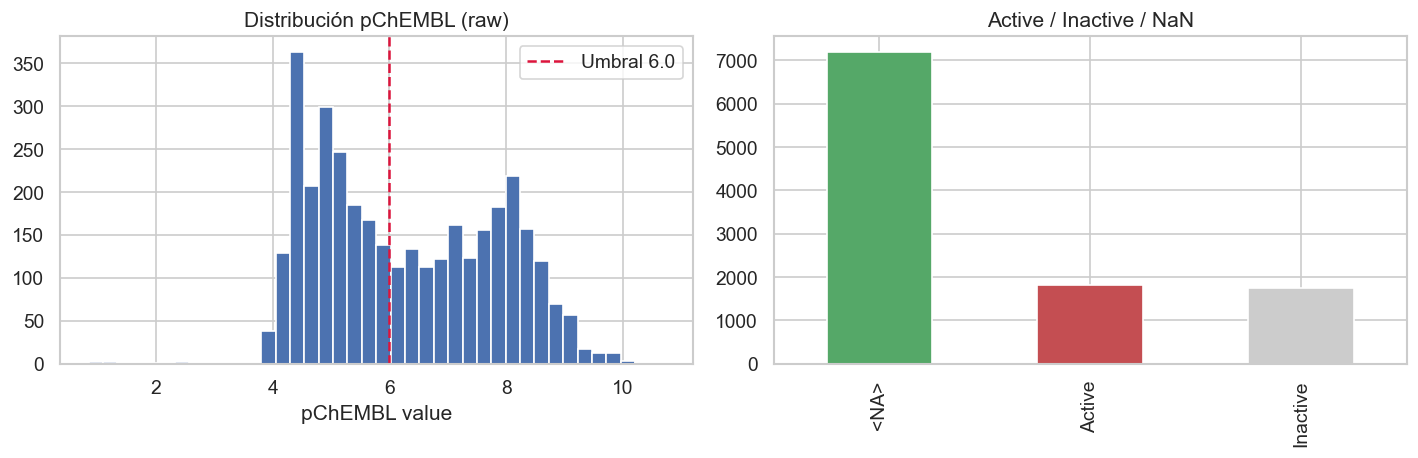

In [6]:
if len(raw_df):
    class_counts = raw_df["activity_class"].value_counts(dropna=False)
    print("Distribución activity_class (dataset raw):")
    display(class_counts.to_frame("n"))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    raw_df["pchembl_value"].dropna().hist(bins=40, ax=axes[0], color="#4C72B0", edgecolor="white")
    axes[0].axvline(PCHEMBL_ACTIVE_THRESHOLD, color="crimson", ls="--", label=f"Umbral {PCHEMBL_ACTIVE_THRESHOLD}")
    axes[0].set_title("Distribución pChEMBL (raw)")
    axes[0].set_xlabel("pChEMBL value")
    axes[0].legend()

    class_counts.plot(kind="bar", ax=axes[1], color=["#55A868", "#C44E52", "#CCCCCC"][: len(class_counts)])
    axes[1].set_title("Active / Inactive / NaN")
    axes[1].set_xlabel("")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "pchembl_and_activity_class_raw.png", bbox_inches="tight")
    plt.show()
else:
    print("Sin datos para visualizar.")

## 5. Filtros de calidad y trazabilidad

Reglas aplicadas al dataset de análisis (configurable en `config.yaml` → `chembl.quality_filters`):
1. **Imputar** `pchembl_value` desde `standard_value` (nM) cuando falte y `standard_relation = '='`
2. Excluir filas sin `pchembl_value` tras imputación
3. Excluir `standard_relation != '='`
4. Excluir `data_validity_comment` no nulo

In [7]:
if len(raw_df):
    clean_df, filter_stats = apply_quality_filters_from_config(
        raw_df, ROOT / "config" / "config.yaml"
    )

    print(f"Registros raw:   {len(raw_df):,}")
    print(f"Registros clean: {len(clean_df):,}")
    print(f"Excluidos:       {len(raw_df) - len(clean_df):,}\n")

    display(filter_stats)
    clean_df.to_csv(CLEAN_CSV, index=False)
    print(f"\nGuardado: {CLEAN_CSV}")
else:
    clean_df = raw_df.copy()
    filter_stats = pd.DataFrame()
    print("Dataset vacío — no se aplicaron filtros.")

Registros raw:   10,745
Registros clean: 3,608
Excluidos:       7,137



,filtro,registros_afectados,pct_del_total
0,pchembl_value nulo (tras imputación),6437,59.91
1,standard_relation != '=',3678,34.23
2,data_validity_comment no nulo,917,8.53
3,TOTAL excluidos (unión de reglas),7137,66.42
4,TOTAL conservados,3608,33.58



Guardado: c:\Users\mateo\Desktop\JIC2026\data\raw\chembl_panama_bioactivity.csv


## 6. Resumen por compuesto

,compound_name,family,chembl_id,match_status,n_activities_raw,n_activities_clean
0,Chlorpyrifos,mixed,CHEMBL463210,ok,106,23
1,Malathion,mixed,CHEMBL1200468,ok,81,10
2,Dimethoate,mixed,CHEMBL1569524,ok,26,4
3,Methyl parathion,mixed,CHEMBL346516,ok,38,20
4,Carbaryl,mixed,CHEMBL46917,ok,125,18
...,...,...,...,...,...,...
230,CID_4610,Herbicides,CHEMBL1356279,ok,3,1
231,CID_4756,Herbicides,CHEMBL1625467,ok,0,0
232,CID_4781,Herbicides,CHEMBL101,ok,297,40
233,CID_4933,Herbicides,CHEMBL1222498,ok,25,4


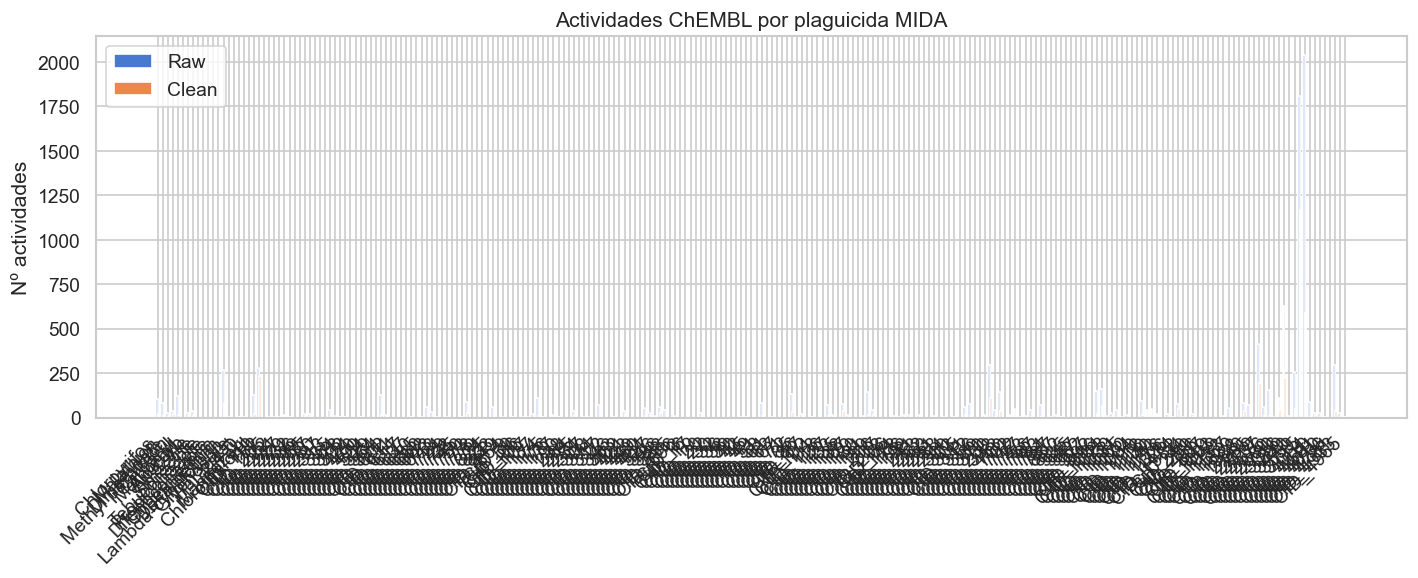


=== Extracción completada ===
  Compuestos MIDA:  235
  ChEMBL mapeados:  172
  Actividades raw:  10,745
  Actividades clean:3,608


In [8]:
summary_df = summarize_extraction(compounds_df, mapping_df, raw_df, clean_df)
display(summary_df)

if len(clean_df):
    fig, ax = plt.subplots(figsize=(12, 5))
    x = range(len(summary_df))
    w = 0.35
    ax.bar([i - w/2 for i in x], summary_df["n_activities_raw"], width=w, label="Raw")
    ax.bar([i + w/2 for i in x], summary_df["n_activities_clean"], width=w, label="Clean")
    ax.set_xticks(list(x))
    ax.set_xticklabels(summary_df["compound_name"], rotation=45, ha="right")
    ax.set_ylabel("Nº actividades")
    ax.set_title("Actividades ChEMBL por plaguicida MIDA")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "activities_per_compound.png", bbox_inches="tight")
    plt.show()

print("\n=== Extracción completada ===")
print(f"  Compuestos MIDA:  {len(compounds_df)}")
print(f"  ChEMBL mapeados:  {mapping_df['chembl_id'].notna().sum()}")
print(f"  Actividades raw:  {len(raw_df):,}")
print(f"  Actividades clean:{len(clean_df):,}")